# EMA 21/13/8 Scalping Strategy — Crypto (H1 + M5)

This notebook is the **crypto** companion to `03_strategy03.ipynb` (forex). Strategy rules are the same; **pending-order distance uses a configurable tick size** suited to digital assets.

1. Load data from local cache (`./data/<symbol>/<timeframe>`)
2. Build EMA indicators (`21`, `13`, `8`)
3. Use `H1` as trend confirmation
4. On `M5`, place a pending stop beyond the last `5` candles high/low (`PENDING_OFFSET_TICKS` × `PIP_SIZE` price units)
5. Use `TP:SL = 1:1`
6. Expire pending orders after `60 minutes`
7. Backtest and save results under `./results/strategy03_crypto/...`

Reference video: https://www.youtube.com/watch?v=zhEukjCzXwM


In [12]:
# SECTION 1 - Imports and parameters
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

# Resolve project root so `strategy` imports (notebook cwd is usually notebooks/).
_ROOT = Path.cwd().resolve()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from strategy.crypto_core import EMA_FAST, EMA_MID, EMA_SLOW, default_crypto_tick

plt.style.use("seaborn-v0_8-darkgrid")

# === User parameters (crypto quotes) ===
SYMBOL = "BTCUSD"
# e.g. BTCUSD, ETHUSD, XRPUSD, BCHUSD, BNBUSD, SOLUSD, TRXUSD, DOGEUSD, LNKUSD, UNIUSD,
#  LTCUSD, ADAUSD, AVEUSD, AVXUSD ...
TF_ENTRY = "M5"
TF_TREND = "H1"

LOOKBACK_BARS = 5
# Pending stop distance beyond swing = PENDING_OFFSET_TICKS * PIP_SIZE (price units).
PENDING_OFFSET_TICKS = 3.0
PENDING_EXPIRY_MIN = 60
RR = 1.0  # TP:SL = 1:1

PIP_SIZE = default_crypto_tick(SYMBOL)
# Backtest engine uses this name; value is tick/step size for crypto.
PENDING_OFFSET_PIPS = float(PENDING_OFFSET_TICKS)

START_BALANCE = 10000.0
RISK_PER_TRADE = 0.01

# Limit backtest/chart M5 history to the last BARS rows (trim applied in Section 4 after H1→M5 mapping).
# EMA + merge still see full loaded history first so rows inside the window are warmed up.
BARS = 400  # e.g. 2000

print(
    f"Symbol={SYMBOL}, Trend={TF_TREND}, Entry={TF_ENTRY}, "
    f"PIP_SIZE(tick)={PIP_SIZE}, offset_ticks={PENDING_OFFSET_TICKS}, BARS={BARS}"
)


Symbol=BTCUSD, Trend=H1, Entry=M5, PIP_SIZE(tick)=1.0, offset_ticks=3.0, BARS=400


In [13]:
# SECTION 2 - Load data from cache: ./data/<symbol>/<timeframe>
def _standardize_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        "Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume",
        "o": "open", "h": "high", "l": "low", "c": "close", "v": "volume",
        "tick_volume": "volume",
    }
    df = df.rename(columns=rename_map)

    if not isinstance(df.index, pd.DatetimeIndex):
        dt_cols = [c for c in ["time", "datetime", "date", "timestamp"] if c in df.columns]
        if dt_cols:
            dt_col = dt_cols[0]
            df[dt_col] = pd.to_datetime(df[dt_col], utc=False, errors="coerce")
            df = df.set_index(dt_col)
        else:
            first = df.columns[0]
            maybe_dt = pd.to_datetime(df[first], utc=False, errors="coerce")
            if maybe_dt.notna().mean() > 0.8:
                df[first] = maybe_dt
                df = df.set_index(first)

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Could not infer datetime index from cache file.")

    need = ["open", "high", "low", "close"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise ValueError(f"Missing OHLC columns: {miss}")

    if "volume" not in df.columns:
        df["volume"] = 1.0

    out = df[["open", "high", "low", "close", "volume"]].copy()
    out = out.sort_index().dropna()
    return out


def load_cached_timeframe(symbol: str, timeframe: str, base_dir: str = "./data") -> pd.DataFrame:
    folder = Path(base_dir) / symbol / timeframe
    if not folder.exists():
        # fallback to lowercase timeframe folders if needed
        alt = Path(base_dir) / symbol / timeframe.lower()
        if alt.exists():
            folder = alt
        else:
            raise FileNotFoundError(f"Cache folder not found: {folder}")

    files = sorted(
        [*folder.glob("*.parquet"), *folder.glob("*.csv")],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not files:
        raise FileNotFoundError(f"No cache file found in {folder}")

    path = files[0]
    df = pd.read_parquet(path) if path.suffix.lower() == ".parquet" else pd.read_csv(path)
    df = _standardize_ohlcv(df)
    print(f"Loaded {len(df):,} rows from {path}")
    return df

m5 = load_cached_timeframe(SYMBOL, TF_ENTRY)
h1 = load_cached_timeframe(SYMBOL, TF_TREND)

display(m5.head(3))
display(h1.head(3))

Loaded 778,984 rows from data\BTCUSD\M5\ohlcv.csv
Loaded 68,295 rows from data\BTCUSD\H1\ohlcv.csv


,open,high,low,close,volume
time,,,,,
2014-11-05 00:00:00+00:00,322.13,335.99,321.55,331.88,4549
2014-11-06 00:00:00+00:00,331.88,345.35,329.10,341.00,4172
2014-11-07 00:00:00+00:00,341.00,347.00,334.01,336.60,4234


,open,high,low,close,volume
time,,,,,
2014-11-05 00:00:00+00:00,322.13,335.99,321.55,331.88,4549
2014-11-06 00:00:00+00:00,331.88,345.35,329.10,341.00,4172
2014-11-07 00:00:00+00:00,341.00,347.00,334.01,336.60,4234


In [14]:
# SECTION 3 - Build EMA 21/13/8 on both timeframes
from strategy.crypto_core import add_emas

m5 = add_emas(m5)
h1 = add_emas(h1)

print("EMA columns added.")
display(h1[["close", f"ema_{EMA_FAST}", f"ema_{EMA_MID}", f"ema_{EMA_SLOW}"]].tail(5))

EMA columns added.


,close,ema_8,ema_13,ema_21
time,,,,
2026-05-10 08:00:00+00:00,80687.42,80717.304395,80688.205502,80620.408606
2026-05-10 09:00:00+00:00,80719.45,80717.781196,80692.669002,80629.412369
2026-05-10 10:00:00+00:00,80721.50,80718.607597,80696.787716,80637.783972
2026-05-10 11:00:00+00:00,80817.16,80740.508131,80713.983756,80654.090883
2026-05-10 12:00:00+00:00,80850.18,80764.879657,80733.440362,80671.917167


In [15]:
# SECTION 4 - H1 trend direction confirmation
# Bull trend: EMA8 > EMA13 > EMA21 and close > EMA21
# Bear trend: EMA8 < EMA13 < EMA21 and close < EMA21
from strategy.crypto_core import merge_h1_trend_onto_m5

m5_ctx = merge_h1_trend_onto_m5(m5, h1)

print(m5_ctx["trend"].value_counts(dropna=False))

if BARS is not None:
    _bars_n = int(BARS)
    if _bars_n > 0:
        _before = len(m5_ctx)
        m5_ctx = m5_ctx.iloc[-_bars_n:].copy()
        m5 = m5.loc[m5_ctx.index].copy()
        if _before > _bars_n:
            print(f"BARS={_bars_n}: trimmed M5 window {_before} -> {len(m5_ctx)} rows")
        if len(m5_ctx) < LOOKBACK_BARS + 2:
            print(
                f"Warning: only {len(m5_ctx)} M5 bars after trim; "
                f"strategy loop starts after LOOKBACK_BARS={LOOKBACK_BARS}."
            )


display(m5_ctx[["close", "trend"]].tail(8))

trend
bull    322650
bear    292942
flat    163392
Name: count, dtype: int64
BARS=400: trimmed M5 window 778984 -> 400 rows


,close,trend
time,,
2026-05-10 11:35:00+00:00,80839.82,bull
2026-05-10 11:40:00+00:00,80822.75,bull
2026-05-10 11:45:00+00:00,80836.71,bull
2026-05-10 11:50:00+00:00,80826.02,bull
2026-05-10 11:55:00+00:00,80817.16,bull
2026-05-10 12:00:00+00:00,80893.90,bull
2026-05-10 12:05:00+00:00,80850.31,bull
2026-05-10 12:10:00+00:00,80850.47,bull


In [16]:
# SECTION 5 - Strategy engine (pending stop orders + expiry + TP/SL)
from strategy.backtest import run_backtest

trades_df, equity_curve = run_backtest(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
    pending_expiry_min=PENDING_EXPIRY_MIN,
    entry_timeframe_minutes=5,
)
print(f"Total trades: {len(trades_df)}")
display(trades_df.head(10))

Total trades: 10


,entry_time,exit_time,side,entry,sl,tp,exit,qty,pnl,balance_after,result
0,2026-05-09 03:30:00+00:00,2026-05-09 04:10:00+00:00,buy,80196.48,80110.71,80282.25,80282.25,1.165909,100.000000,10100.000000,win
1,2026-05-09 04:30:00+00:00,2026-05-09 05:10:00+00:00,buy,80310.62,80173.67,80447.57,80447.57,0.737495,101.000000,10201.000000,win
2,2026-05-09 05:30:00+00:00,2026-05-09 06:40:00+00:00,buy,80456.33,80310.26,80602.40,80310.26,0.698364,-102.010000,10098.990000,loss
3,2026-05-09 07:05:00+00:00,2026-05-09 09:20:00+00:00,buy,80538.35,80290.35,80786.35,80290.35,0.407217,-100.989900,9998.000100,loss
4,2026-05-09 11:00:00+00:00,2026-05-09 18:35:00+00:00,buy,80297.82,80117.58,80478.06,80478.06,0.554705,99.980001,10097.980101,win
5,2026-05-09 18:45:00+00:00,2026-05-09 19:20:00+00:00,buy,80516.28,80282.04,80750.52,80750.52,0.431095,100.979801,10198.959902,win
6,2026-05-09 20:10:00+00:00,2026-05-09 21:30:00+00:00,buy,80765.80,80470.00,81061.60,81061.60,0.344792,101.989599,10300.949501,win
7,2026-05-09 22:50:00+00:00,2026-05-09 23:20:00+00:00,buy,80907.74,80759.44,81056.04,80759.44,0.694602,-103.009495,10197.940006,loss
8,2026-05-10 01:40:00+00:00,2026-05-10 02:25:00+00:00,buy,80776.54,80652.50,80900.58,80652.50,0.822149,-101.979400,10095.960606,loss
9,2026-05-10 04:50:00+00:00,2026-05-10 05:25:00+00:00,buy,80649.43,80555.15,80743.71,80743.71,1.070849,100.959606,10196.920212,win


In [17]:
# SECTION 5b — Entry points (signals vs actual fills)
# - `list_setup_signals`: every closed M5 bar where the model would place a pending (fixed START_BALANCE sizing).
# - `list_trade_entries`: each time a pending actually fills in the same walk-forward rules as `run_backtest`.

from pathlib import Path
import importlib

# Jupyter keeps an old `backtest` in memory after you edit the file — reload before importing new names.
import strategy.backtest as _backtest_mod
importlib.reload(_backtest_mod)
from strategy.setup import list_setup_signals, list_trade_entries

entry_signals_df = list_setup_signals(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
)
entry_fills_df = list_trade_entries(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
    pending_expiry_min=PENDING_EXPIRY_MIN,
    entry_timeframe_minutes=5,
)

print(f"Model entry signals (pending-setup bars): {len(entry_signals_df)}")
print(f"Actual entry fills (pending triggered): {len(entry_fills_df)}")

# Log sample rows to stdout (remove .head(N) to print all — can be long)
for _, r in entry_signals_df.head(15).iterrows():
    print(f"  SIGNAL {r['signal_bar_time']}  {r['side']}  entry={r['entry']:.5g}")
for _, r in entry_fills_df.head(15).iterrows():
    print(
        f"  FILL   signal_bar={r['signal_bar_time']}  entry_time={r['entry_time']}  "
        f"{r['side']}  @ {r['entry']:.5g}"
    )

display(entry_signals_df.head(12))
display(entry_fills_df.head(12))

_entry_out = Path("./results") / "strategy03_crypto" / SYMBOL / TF_ENTRY
_entry_out.mkdir(parents=True, exist_ok=True)
_signals_csv = _entry_out / "entry_signals.csv"
_fills_csv = _entry_out / "entry_fills.csv"
entry_signals_df.to_csv(_signals_csv, index=False)
entry_fills_df.to_csv(_fills_csv, index=False)
print(f"Saved: {_signals_csv}")
print(f"Saved: {_fills_csv}")

Model entry signals (pending-setup bars): 395
Actual entry fills (pending triggered): 11
  SIGNAL 2026-05-09 03:20:00+00:00  buy  entry=80196
  SIGNAL 2026-05-09 03:25:00+00:00  buy  entry=80199
  SIGNAL 2026-05-09 03:30:00+00:00  buy  entry=80199
  SIGNAL 2026-05-09 03:35:00+00:00  buy  entry=80208
  SIGNAL 2026-05-09 03:40:00+00:00  buy  entry=80209
  SIGNAL 2026-05-09 03:45:00+00:00  buy  entry=80209
  SIGNAL 2026-05-09 03:50:00+00:00  buy  entry=80224
  SIGNAL 2026-05-09 03:55:00+00:00  buy  entry=80228
  SIGNAL 2026-05-09 04:00:00+00:00  buy  entry=80231
  SIGNAL 2026-05-09 04:05:00+00:00  buy  entry=80240
  SIGNAL 2026-05-09 04:10:00+00:00  buy  entry=80254
  SIGNAL 2026-05-09 04:15:00+00:00  buy  entry=80311
  SIGNAL 2026-05-09 04:20:00+00:00  buy  entry=80341
  SIGNAL 2026-05-09 04:25:00+00:00  buy  entry=80341
  SIGNAL 2026-05-09 04:30:00+00:00  buy  entry=80341
  FILL   signal_bar=2026-05-09 03:20:00+00:00  entry_time=2026-05-09 03:30:00+00:00  buy  @ 80196
  FILL   signal_ba

,signal_bar_index,signal_bar_time,trend,side,entry,sl,tp,qty
0,5,2026-05-09 03:20:00+00:00,bull,buy,80196.48,80110.71,80282.25,1.165909
1,6,2026-05-09 03:25:00+00:00,bull,buy,80199.33,80110.71,80287.95,1.128413
2,7,2026-05-09 03:30:00+00:00,bull,buy,80199.33,80110.71,80287.95,1.128413
3,8,2026-05-09 03:35:00+00:00,bull,buy,80208.49,80110.71,80306.27,1.022704
4,9,2026-05-09 03:40:00+00:00,bull,buy,80208.74,80110.71,80306.77,1.020096
5,10,2026-05-09 03:45:00+00:00,bull,buy,80208.74,80112.02,80305.46,1.033912
6,11,2026-05-09 03:50:00+00:00,bull,buy,80223.82,80138.09,80309.55,1.166453
7,12,2026-05-09 03:55:00+00:00,bull,buy,80227.84,80138.98,80316.70,1.125366
8,13,2026-05-09 04:00:00+00:00,bull,buy,80231.43,80165.75,80297.11,1.522533
9,14,2026-05-09 04:05:00+00:00,bull,buy,80239.73,80165.75,80313.71,1.351717


,signal_bar_time,signal_bar_index,entry_time,entry_bar_index,side,entry,sl,tp,qty
0,2026-05-09 03:20:00+00:00,5,2026-05-09 03:30:00+00:00,7,buy,80196.48,80110.71,80282.25,1.165909
1,2026-05-09 04:15:00+00:00,16,2026-05-09 04:30:00+00:00,19,buy,80310.62,80173.67,80447.57,0.737495
2,2026-05-09 05:15:00+00:00,28,2026-05-09 05:30:00+00:00,31,buy,80456.33,80310.26,80602.40,0.698364
3,2026-05-09 06:45:00+00:00,46,2026-05-09 07:05:00+00:00,50,buy,80538.35,80290.35,80786.35,0.407217
4,2026-05-09 10:30:00+00:00,91,2026-05-09 11:00:00+00:00,97,buy,80297.82,80117.58,80478.06,0.554705
5,2026-05-09 18:40:00+00:00,189,2026-05-09 18:45:00+00:00,190,buy,80516.28,80282.04,80750.52,0.431095
6,2026-05-09 19:25:00+00:00,198,2026-05-09 20:10:00+00:00,207,buy,80765.80,80470.00,81061.60,0.344792
7,2026-05-09 22:40:00+00:00,237,2026-05-09 22:50:00+00:00,239,buy,80907.74,80759.44,81056.04,0.694602
8,2026-05-10 01:35:00+00:00,272,2026-05-10 01:40:00+00:00,273,buy,80776.54,80652.50,80900.58,0.822149
9,2026-05-10 04:40:00+00:00,309,2026-05-10 04:50:00+00:00,311,buy,80649.43,80555.15,80743.71,1.070849


Saved: results\strategy03_crypto\BTCUSD\M5\entry_signals.csv
Saved: results\strategy03_crypto\BTCUSD\M5\entry_fills.csv


In [18]:
# SECTION 6 - Backtest metrics (pilot result numbers)
def max_drawdown_pct(equity: pd.Series | None) -> float:
    """Peak-to-trough drawdown as % of running peak equity."""
    if equity is None or len(equity) < 2:
        return 0.0
    eq = pd.Series(equity).astype(float).dropna()
    if eq.empty:
        return 0.0
    peak = eq.cummax()
    dd = (eq - peak) / peak.replace(0, np.nan)
    return float(abs(dd.min()) * 100.0)


def summarize_results(
    trades: pd.DataFrame,
    start_balance: float,
    equity: pd.Series | None = None,
) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame([{
            "trades": 0,
            "win_rate_%": 0.0,
            "net_pnl": 0.0,
            "avg_pnl": 0.0,
            "profit_factor": 0.0,
            "max_drawdown_%": round(max_drawdown_pct(equity), 2),
            "start_balance": start_balance,
            "end_balance": start_balance,
            "return_%": 0.0,
        }])

    wins = trades[trades["pnl"] > 0]["pnl"]
    losses = trades[trades["pnl"] < 0]["pnl"]

    gross_profit = wins.sum() if not wins.empty else 0.0
    gross_loss = abs(losses.sum()) if not losses.empty else 0.0
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

    end_balance = trades["balance_after"].iloc[-1]
    result = {
        "trades": int(len(trades)),
        "win_rate_%": round((trades["pnl"] > 0).mean() * 100, 2),
        "net_pnl": round(trades["pnl"].sum(), 2),
        "avg_pnl": round(trades["pnl"].mean(), 2),
        "profit_factor": round(float(profit_factor), 3) if pd.notna(profit_factor) else np.nan,
        "max_drawdown_%": round(max_drawdown_pct(equity), 2),
        "start_balance": round(start_balance, 2),
        "end_balance": round(float(end_balance), 2),
        "return_%": round(((end_balance / start_balance) - 1) * 100, 2),
    }
    return pd.DataFrame([result])


# Trade columns: price difference (exit - entry) and running sum of pnl (last column)
if not trades_df.empty:
    trades_df = trades_df.copy()
    trades_df["exit_minus_entry"] = trades_df["exit"] - trades_df["entry"]
    trades_df["cumulative_pnl"] = trades_df["pnl"].cumsum()
    _base_cols = [c for c in trades_df.columns if c not in ("exit_minus_entry", "cumulative_pnl")]
    trades_df = trades_df[_base_cols + ["exit_minus_entry", "cumulative_pnl"]]

summary = summarize_results(trades_df, START_BALANCE, equity_curve)
display(summary)

if not trades_df.empty:
    display(trades_df.tail(10))

,trades,win_rate_%,net_pnl,avg_pnl,profit_factor,max_drawdown_%,start_balance,end_balance,return_%
0,10,60.0,196.92,19.69,1.483,2.86,10000.0,10196.92,1.97


,entry_time,exit_time,side,entry,sl,tp,exit,qty,pnl,balance_after,result,exit_minus_entry,cumulative_pnl
0,2026-05-09 03:30:00+00:00,2026-05-09 04:10:00+00:00,buy,80196.48,80110.71,80282.25,80282.25,1.165909,100.000000,10100.000000,win,85.77,100.000000
1,2026-05-09 04:30:00+00:00,2026-05-09 05:10:00+00:00,buy,80310.62,80173.67,80447.57,80447.57,0.737495,101.000000,10201.000000,win,136.95,201.000000
2,2026-05-09 05:30:00+00:00,2026-05-09 06:40:00+00:00,buy,80456.33,80310.26,80602.40,80310.26,0.698364,-102.010000,10098.990000,loss,-146.07,98.990000
3,2026-05-09 07:05:00+00:00,2026-05-09 09:20:00+00:00,buy,80538.35,80290.35,80786.35,80290.35,0.407217,-100.989900,9998.000100,loss,-248.00,-1.999900
4,2026-05-09 11:00:00+00:00,2026-05-09 18:35:00+00:00,buy,80297.82,80117.58,80478.06,80478.06,0.554705,99.980001,10097.980101,win,180.24,97.980101
5,2026-05-09 18:45:00+00:00,2026-05-09 19:20:00+00:00,buy,80516.28,80282.04,80750.52,80750.52,0.431095,100.979801,10198.959902,win,234.24,198.959902
6,2026-05-09 20:10:00+00:00,2026-05-09 21:30:00+00:00,buy,80765.80,80470.00,81061.60,81061.60,0.344792,101.989599,10300.949501,win,295.80,300.949501
7,2026-05-09 22:50:00+00:00,2026-05-09 23:20:00+00:00,buy,80907.74,80759.44,81056.04,80759.44,0.694602,-103.009495,10197.940006,loss,-148.30,197.940006
8,2026-05-10 01:40:00+00:00,2026-05-10 02:25:00+00:00,buy,80776.54,80652.50,80900.58,80652.50,0.822149,-101.979400,10095.960606,loss,-124.04,95.960606
9,2026-05-10 04:50:00+00:00,2026-05-10 05:25:00+00:00,buy,80649.43,80555.15,80743.71,80743.71,1.070849,100.959606,10196.920212,win,94.28,196.920212


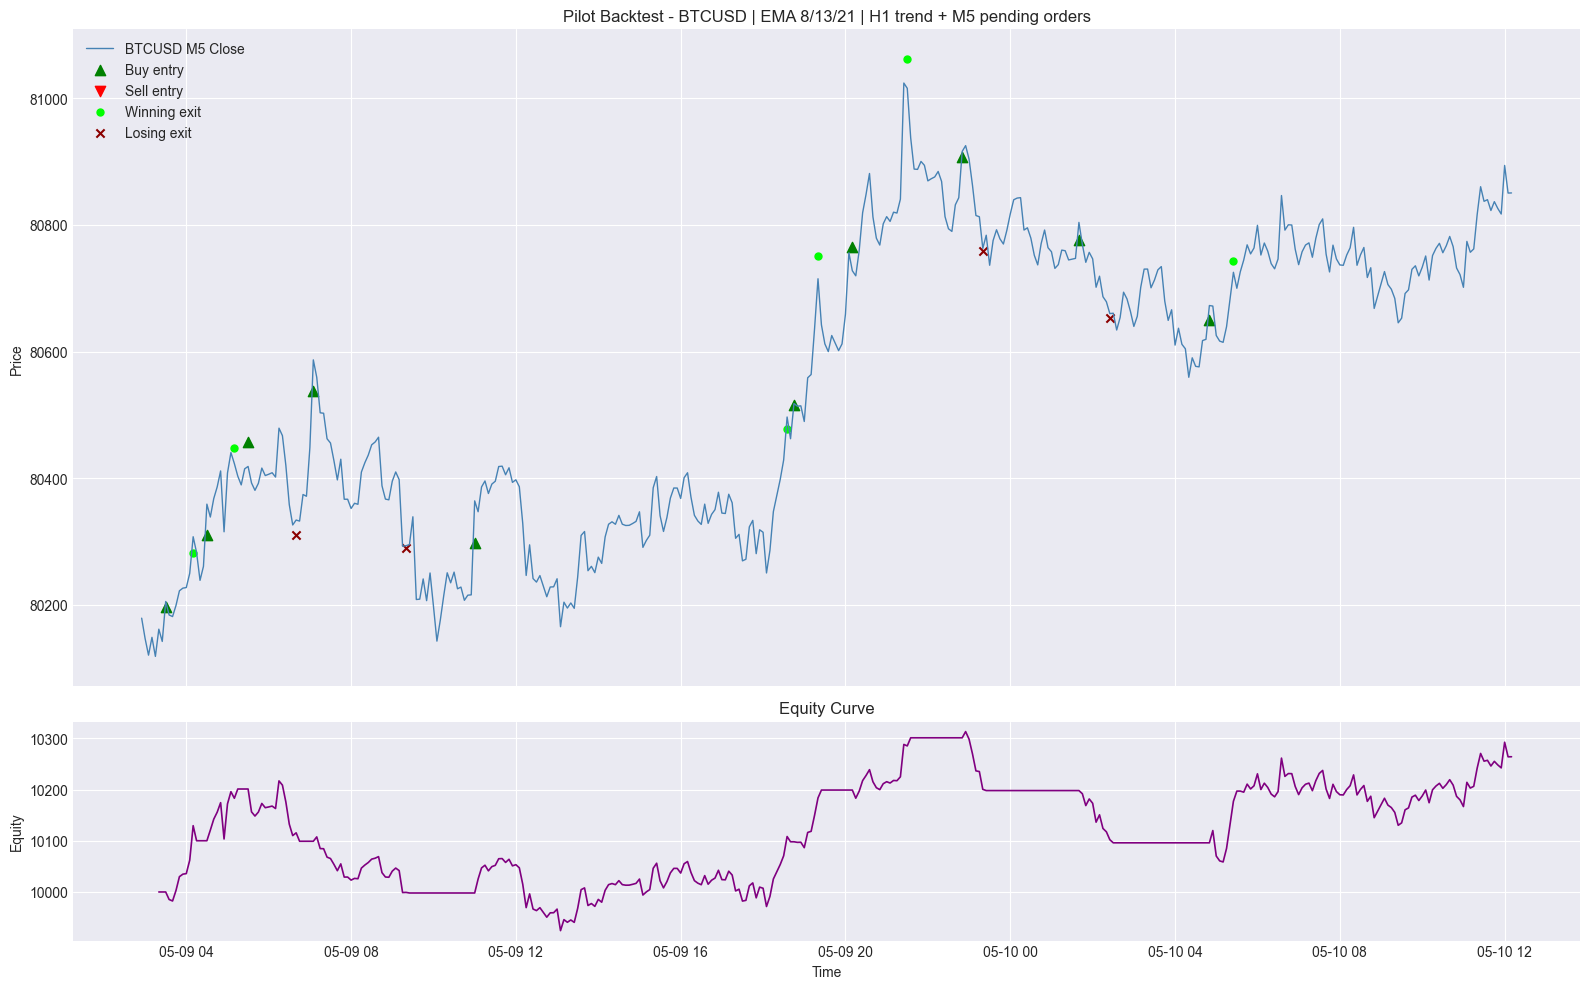

In [19]:
# SECTION 7 - Pilot result chart (price + entries/exits + equity)
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax_price, ax_eq = axes

# price line (you can replace with candlestick later)
ax_price.plot(m5_ctx.index, m5_ctx["close"], label=f"{SYMBOL} M5 Close", color="steelblue", linewidth=1.0)

if not trades_df.empty:
    buys = trades_df[trades_df["side"] == "buy"]
    sells = trades_df[trades_df["side"] == "sell"]

    ax_price.scatter(buys["entry_time"], buys["entry"], marker="^", color="green", s=55, label="Buy entry")
    ax_price.scatter(sells["entry_time"], sells["entry"], marker="v", color="red", s=55, label="Sell entry")

    win_trades = trades_df[trades_df["pnl"] > 0]
    loss_trades = trades_df[trades_df["pnl"] <= 0]

    ax_price.scatter(win_trades["exit_time"], win_trades["exit"], marker="o", color="lime", s=25, label="Winning exit")
    ax_price.scatter(loss_trades["exit_time"], loss_trades["exit"], marker="x", color="darkred", s=35, label="Losing exit")

ax_price.set_title(f"Pilot Backtest - {SYMBOL} | EMA {EMA_FAST}/{EMA_MID}/{EMA_SLOW} | H1 trend + M5 pending orders")
ax_price.set_ylabel("Price")
ax_price.legend(loc="upper left")

if equity_curve is not None and len(equity_curve) > 0:
    ax_eq.plot(equity_curve.index, equity_curve.values, color="purple", linewidth=1.2)
ax_eq.set_title("Equity Curve")
ax_eq.set_ylabel("Equity")
ax_eq.set_xlabel("Time")

plt.tight_layout()
plt.show()

## Notes and tuning ideas

- Same structure as the forex notebook (`03_strategy03.ipynb`); results save under `results/strategy03_crypto/` so runs do not overwrite FX outputs.
- **Tick size**: If pending orders sit too tight or too wide versus your cached OHLC, assign `PIP_SIZE` explicitly after the helper (must match your data’s minimum price step).
- For stricter trend filter, require H1 candle close above/below all EMAs.
- For lower trade frequency, increase `LOOKBACK_BARS` from `5` to `8–12`.
- For different risk profile, change `RISK_PER_TRADE` and `RR`.

Video reference: https://www.youtube.com/watch?v=zhEukjCzXwM


In [20]:
# SECTION 8 - Save results to folder
# Crypto variant output path:
# ./results/strategy03_crypto/{{symbol}}/{{timeframe}}/merics.csv
# ./results/strategy03_crypto/{{symbol}}/{{timeframe}}/trades.csv

RESULT_BASE = Path("./results") / "strategy03_crypto"
RESULT_SYMBOL = SYMBOL
RESULT_TIMEFRAME = TF_ENTRY  # you asked path with {{timeframe}}

result_dir = RESULT_BASE / RESULT_SYMBOL / RESULT_TIMEFRAME
result_dir.mkdir(parents=True, exist_ok=True)

metrics_path = result_dir / "merics.csv"   # kept exact requested filename
trades_path = result_dir / "trades.csv"

summary.to_csv(metrics_path, index=False)

if trades_df is None or trades_df.empty:
    pd.DataFrame(columns=[
        "entry_time", "exit_time", "side", "entry", "sl", "tp", "exit",
        "qty", "pnl", "balance_after", "result",
        "exit_minus_entry", "cumulative_pnl",
    ]).to_csv(trades_path, index=False)
else:
    trades_df.to_csv(trades_path, index=False)

print(f"Created folder: {result_dir}")
print(f"Saved metrics: {metrics_path}")
print(f"Saved trades : {trades_path}")


Created folder: results\strategy03_crypto\BTCUSD\M5
Saved metrics: results\strategy03_crypto\BTCUSD\M5\merics.csv
Saved trades : results\strategy03_crypto\BTCUSD\M5\trades.csv


In [21]:
# SECTION 9 - Interactive Plotly chart (last 1500 M5 bars + last 5 entries + RSI)
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

N_LAST_TRADES = 5
RSI_PERIOD = 14
BAR_TAIL = 1500


def compute_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta.clip(upper=0))
    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


ind = m5_ctx.sort_index().reset_index()
first_col = ind.columns[0]
if first_col != "time":
    ind = ind.rename(columns={first_col: "time"})
ind = ind.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
})

ind["ema_fast"] = ind[f"ema_{EMA_FAST}"]
ind["ema_medium"] = ind[f"ema_{EMA_MID}"]
ind["ema_slow"] = ind[f"ema_{EMA_SLOW}"]
ind["rsi"] = compute_rsi(ind["Close"], RSI_PERIOD)

tail = ind.tail(BAR_TAIL)

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.65, 0.35],
    vertical_spacing=0.04,
)

fig.add_trace(
    go.Candlestick(
        x=tail["time"],
        open=tail["Open"],
        high=tail["High"],
        low=tail["Low"],
        close=tail["Close"],
        name=f"{SYMBOL} M5",
    ),
    row=1,
    col=1,
)

for ema, color in zip(
    ["ema_fast", "ema_medium", "ema_slow"],
    ["#00cc96", "#636efa", "#ef553b"],
):
    fig.add_trace(
        go.Scatter(
            x=tail["time"],
            y=tail[ema],
            name=ema,
            line=dict(color=color, width=1),
        ),
        row=1,
        col=1,
    )

fig.add_trace(
    go.Scatter(
        x=tail["time"],
        y=tail["rsi"],
        name="RSI",
        line=dict(color="#ab63fa"),
    ),
    row=2,
    col=1,
)

fig.add_hline(y=51, line_dash="dot", row=2, col=1)
fig.add_hline(y=49, line_dash="dot", row=2, col=1)

if trades_df is not None and not trades_df.empty:
    last5 = trades_df.tail(N_LAST_TRADES).copy()
    et = pd.to_datetime(last5["entry_time"], utc=False, errors="coerce")
    sym_mrk = [
        "triangle-up" if str(s).lower() == "buy" else "triangle-down"
        for s in last5["side"]
    ]
    cols = ["#2ca02c" if str(s).lower() == "buy" else "#d62728" for s in last5["side"]]
    hover_lines = []
    for _, r in last5.iterrows():
        parts = [
            f"<b>{str(r['side']).upper()}</b>",
            f"entry {float(r['entry']):.5f}",
            f"SL {float(r['sl']):.5f}  TP {float(r['tp']):.5f}",
            f"exit {float(r['exit']):.5f}  pnl {float(r['pnl']):.2f}  {r.get('result', '')}",
        ]
        if "cumulative_pnl" in last5.columns and pd.notna(r.get("cumulative_pnl")):
            parts.append(f"cumulative_pnl {float(r['cumulative_pnl']):.2f}")
        hover_lines.append("<br>".join(parts))

    fig.add_trace(
        go.Scatter(
            x=et,
            y=last5["entry"].astype(float),
            mode="markers",
            marker=dict(size=13, color=cols, symbol=sym_mrk, line=dict(width=1, color="white")),
            name=f"Last {N_LAST_TRADES} entries",
            text=hover_lines,
            hovertemplate="%{text}<extra></extra>",
        ),
        row=1,
        col=1,
    )

fig.update_layout(
    height=650,
    xaxis_rangeslider_visible=False,
    template="plotly_dark",
    title=dict(text=f"{SYMBOL} — tail({BAR_TAIL}) M5 bars + last {N_LAST_TRADES} entries (hover markers)"),
)

fig.show()


## SECTION 10 — Four-week (28-day) metrics

Trades are grouped into consecutive **28-day** windows from the **first exit** (UTC, midnight-normalized anchor). Assignment uses each trade’s **`exit_time`**. **`start_balance`** / **`end_balance`** chain forward from **`START_BALANCE`** like a month-by-month account simulation (windows with no trades keep the same balance).


In [22]:
# SECTION 10 — Four-week (28-day) metrics
from IPython.display import display

PERIOD_DAYS = 28  # four weeks per bucket


def _four_week_metrics(trades: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "period_idx",
        "period_start",
        "period_end_inclusive",
        "trades",
        "win_rate_%",
        "net_pnl",
        "avg_pnl",
        "profit_factor",
        "start_balance",
        "end_balance",
        "return_%",
    ]
    empty = pd.DataFrame(columns=cols)
    if trades is None or trades.empty:
        return empty

    td = trades.copy()
    td["_exit"] = pd.to_datetime(td["exit_time"], utc=True, errors="coerce")
    td = td.loc[td["_exit"].notna()].sort_values("_exit")
    if td.empty:
        return empty

    anchor = td["_exit"].min().normalize()
    td["_bucket"] = ((td["_exit"] - anchor).dt.days // PERIOD_DAYS).astype(int)

    min_b = int(td["_bucket"].min())
    max_b = int(td["_bucket"].max())

    rows: list[dict] = []
    running_bal = float(START_BALANCE)

    for b in range(min_b, max_b + 1):
        chunk = td.loc[td["_bucket"] == b]
        p_start = anchor + pd.Timedelta(days=b * PERIOD_DAYS)
        p_end_excl = anchor + pd.Timedelta(days=(b + 1) * PERIOD_DAYS)
        pend_inc = (p_end_excl - pd.Timedelta(days=1)).date()

        if chunk.empty:
            rows.append(
                {
                    "period_idx": b,
                    "period_start": p_start.date(),
                    "period_end_inclusive": pend_inc,
                    "trades": 0,
                    "win_rate_%": 0.0,
                    "net_pnl": 0.0,
                    "avg_pnl": 0.0,
                    "profit_factor": np.nan,
                    "start_balance": round(running_bal, 2),
                    "end_balance": round(running_bal, 2),
                    "return_%": 0.0,
                }
            )
            continue

        net = float(chunk["pnl"].sum())
        wins = chunk.loc[chunk["pnl"] > 0, "pnl"]
        losses = chunk.loc[chunk["pnl"] < 0, "pnl"]
        gross_profit = float(wins.sum()) if not wins.empty else 0.0
        gross_loss = float(losses.abs().sum()) if not losses.empty else 0.0
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

        end_bal = running_bal + net
        rows.append(
            {
                "period_idx": b,
                "period_start": p_start.date(),
                "period_end_inclusive": pend_inc,
                "trades": int(len(chunk)),
                "win_rate_%": round((chunk["pnl"] > 0).mean() * 100, 2),
                "net_pnl": round(net, 2),
                "avg_pnl": round(float(chunk["pnl"].mean()), 2),
                "profit_factor": round(float(profit_factor), 3)
                if pd.notna(profit_factor)
                else np.nan,
                "start_balance": round(running_bal, 2),
                "end_balance": round(end_bal, 2),
                "return_%": round(((end_bal / running_bal) - 1) * 100, 2)
                if running_bal != 0
                else 0.0,
            }
        )
        running_bal = end_bal

    return pd.DataFrame(rows)


four_week_summary = _four_week_metrics(trades_df)
if four_week_summary.empty:
    print("No trades — empty four-week metrics table.")
display(four_week_summary)


,period_idx,period_start,period_end_inclusive,trades,win_rate_%,net_pnl,avg_pnl,profit_factor,start_balance,end_balance,return_%
0,0,2026-05-09,2026-06-05,10,60.0,196.92,19.69,1.483,10000.0,10196.92,1.97
